In [17]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import gc

In [18]:
ds_sla = xr.open_dataset('SLA_UPDATED.nc')

In [19]:
ds_gfs = xr.open_dataset('GFS_UPDATED_V1.nc')

In [20]:
ocean_mask = ~ds_sla.sla.isel(time=0).isnull()

In [21]:
lat_idxs,lon_idxs = np.where(ocean_mask)

In [22]:
sla_now = ds_sla.sla

ds_ml = xr.Dataset({
        "sla_now": sla_now,
        
        **{
        f"sla_lag{i}": ds_sla.sla.shift(time=i)
        for i in range(1,15)
        },

        "tmp_surface": ds_gfs.TMP_surface,
        "tmp_2m": ds_gfs.TMP_2maboveground,

        "ugrd": ds_gfs.UGRD_10maboveground,
        "vgrd": ds_gfs.VGRD_10maboveground,

        "dswrf": ds_gfs.DSWRF_surface,
        "uswrf": ds_gfs.USWRF_surface,
        "dlwrf": ds_gfs.DLWRF_surface,
        "ulwrf": ds_gfs.ULWRF_surface,

        "spfh": ds_gfs.SPFH_2maboveground,
        "prate": ds_gfs.PRATE_surface,

        
    })
ds_ml["month"] = ds_ml.time.dt.month
ds_ml["dayofyear"] = ds_ml.time.dt.dayofyear

In [23]:
features = (
    ["sla_now"]
    + [f"sla_lag{i}" for i in range(1,15)]
    + [
        "tmp_surface",
        # "tmp_2m",
        "ugrd",
        "vgrd",
        "dswrf",
        "uswrf",
        "dlwrf",
        "ulwrf",
        "spfh",
        "prate",
        "month",
        "dayofyear",
        "latitude",
        "longitude"
    ]
)

In [24]:
ds_ml = ds_ml.stack(
    point=("latitude","longitude")
)
df_features = (ds_ml.to_dataframe().reset_index()).dropna()

In [25]:
def build_Dataset(lead):

    target = ds_sla.sla.shift(time=-lead).where(ocean_mask).stack(point=("latitude","longitude"))
    
    target_df = target.to_dataframe(name="target").reset_index()
    
    df = df_features.merge(
    target_df,
    on=["time","latitude","longitude"]
    )
    
    df = df.dropna(subset=['target'])
    
    train = df[df.time < "2024-01-01"]
    test  = df[df.time >= "2024-01-01"]
    
    X_train = train[features]
    y_train = train["target"]
    X_test = test[features]
    y_test = test["target"]
    
    
    coords_test = test[["time", "latitude", "longitude"]]
    
    return X_train, y_train, X_test, y_test,coords_test

In [26]:
def train_and_evaluate(lead):
    X_train, y_train, X_test, y_test,coords_test = build_Dataset(lead)
    model = XGBRegressor(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device="cuda",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)
    model.set_params(device="cpu")
    pred_xgb = model.predict(X_test)

    rmse_xgb = np.sqrt(
        mean_squared_error(
            y_test,
            pred_xgb
        )
    )
    pred_persistence = X_test["sla_now"]
    rmse_persistence = np.sqrt(
        mean_squared_error(
            y_test,pred_persistence
        )
    )
    
    pred_df = coords_test.copy()

    pred_df["truth"] = y_test.values
    pred_df["xgb"] = pred_xgb
    pred_df["pers"] = pred_persistence.values

    pred_df["err_xgb"] = pred_xgb - y_test.values
    pred_df["err_pers"] = pred_persistence.values - y_test.values
    
    rmse_map = (
        pred_df
        .groupby(["latitude","longitude"])
        .agg(
            rmse_xgb=("err_xgb",
                    lambda x: np.sqrt(np.mean(x**2))),
            rmse_pers=("err_pers",
                    lambda x: np.sqrt(np.mean(x**2)))
        )
        .reset_index()
    )
    
    rmse_map["improvement"] = (
        rmse_map["rmse_pers"]
        - rmse_map["rmse_xgb"]
    )
        
    return rmse_xgb, rmse_persistence, model, X_test,rmse_map,pred_df
    
    

Lead 1: Persistence=0.01848, XGB=0.01968
Lead 2: Persistence=0.02329, XGB=0.02498
Lead 3: Persistence=0.02836, XGB=0.03017
Lead 4: Persistence=0.03372, XGB=0.03523
Lead 5: Persistence=0.03848, XGB=0.03896
Lead 6: Persistence=0.04307, XGB=0.04263
Lead 7: Persistence=0.04710, XGB=0.04543


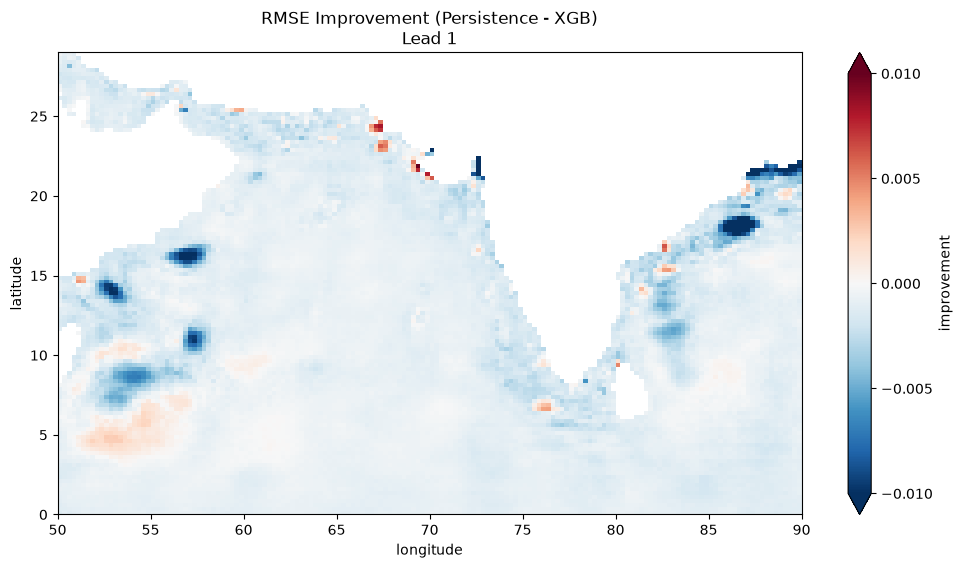

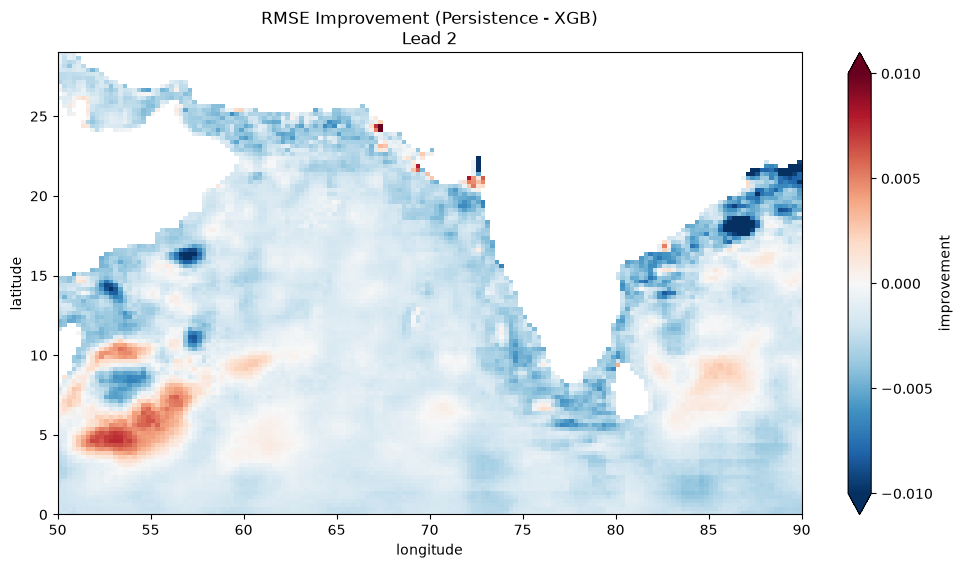

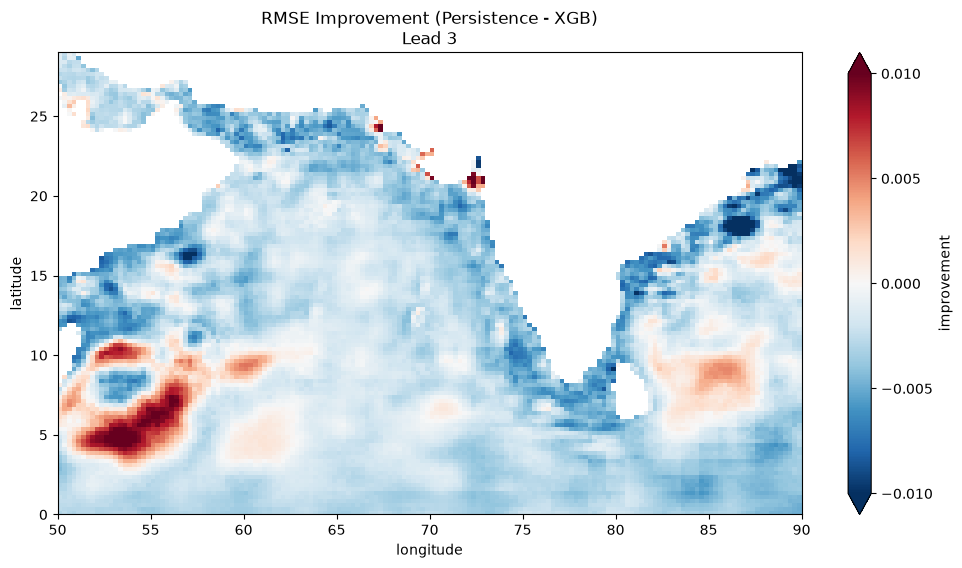

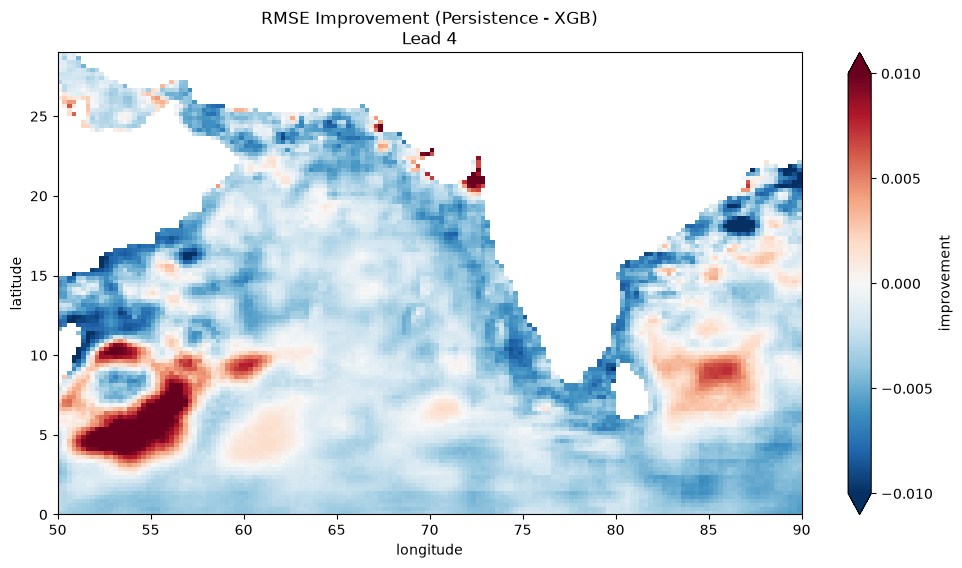

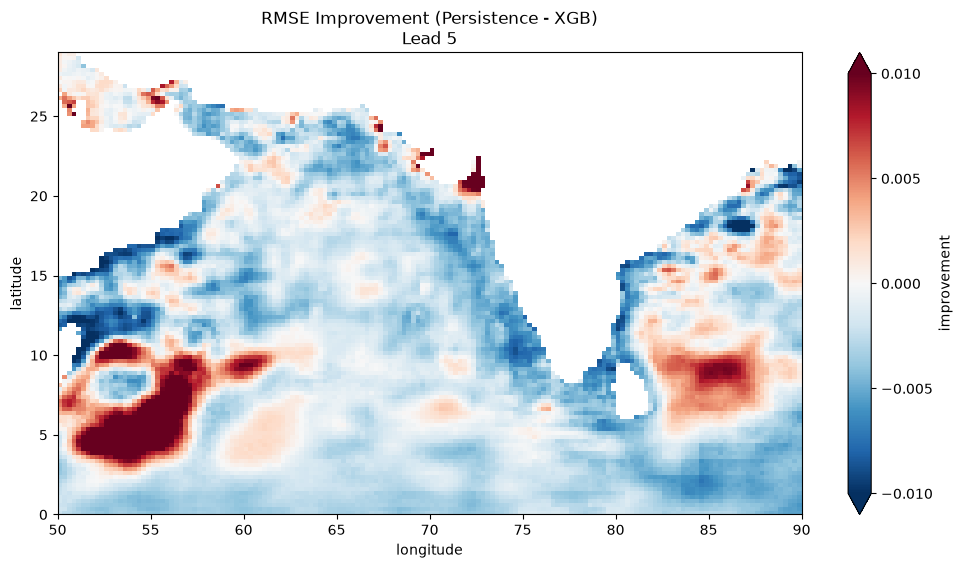

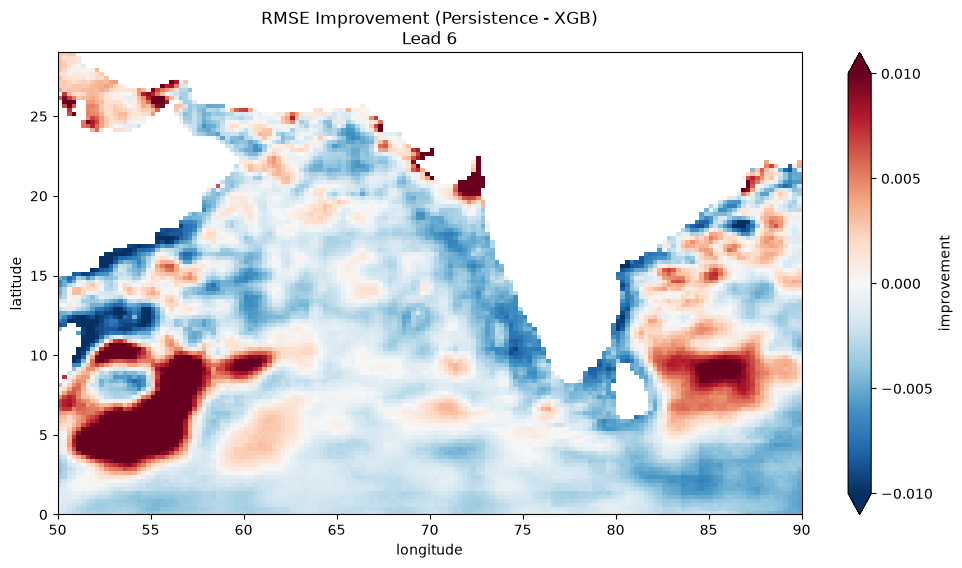

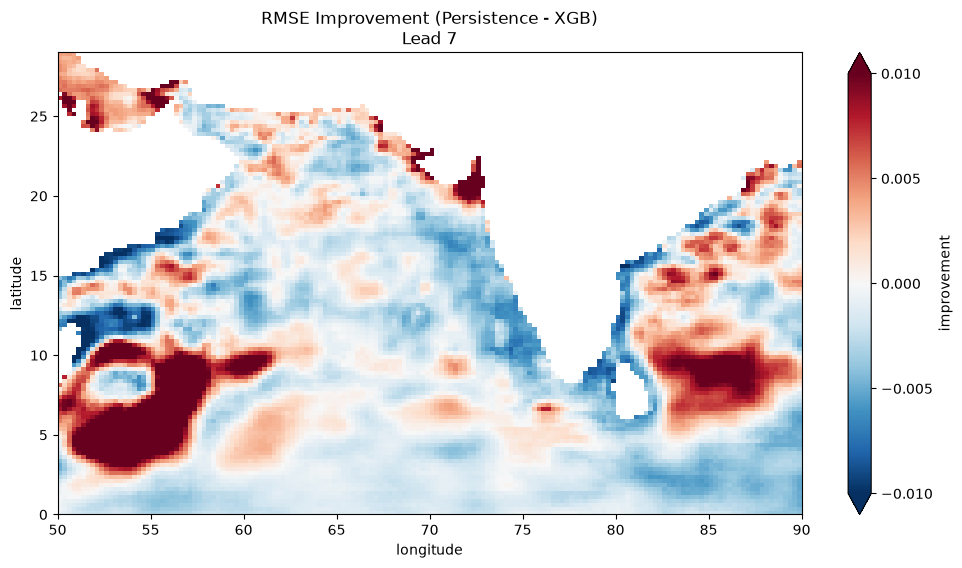

In [27]:
results = []

for lead in range(1, 8):

    rmse_xgb, rmse_persistence, model, X_test,rmse_map,pred_df = train_and_evaluate(lead)

    results.append({
        "lead": lead,
        "xgb": rmse_xgb,
        "persistence": rmse_persistence
    })

    print(
        f"Lead {lead}: "
        f"Persistence={rmse_persistence:.5f}, "
        f"XGB={rmse_xgb:.5f}"
    )
    
    improvement_da = (
    rmse_map
    .set_index(["latitude","longitude"])
    ["improvement"]
    .to_xarray()
    )

    plt.figure(figsize=(12,6))

    improvement_da.plot(
        cmap="RdBu_r",
        vmin=-0.01,
        vmax=0.01,
        cbar_kwargs={
        "ticks": np.linspace(-0.01, 0.01, 5)
        }
    )
    
    # Save RMSE table for this lead
    rmse_map.to_parquet(
        f"xgb_results/rmse_map_lead/rmse_map_lead_{lead}.parquet"
    )

    # Save trained XGBoost model
    model.save_model(
        f"xgb_results/model_info/xgb_lead_{lead}.json"
    )

    # Save gridded improvement map
    improvement_da.to_netcdf(
        f"xgb_results/improv_leadnc/improvement_lead_{lead}.nc"
    )
    
    # Save pred features
    pred_df.to_parquet(
    f"xgb_results/pred_lead/predictions_lead_{lead}.parquet"
    )
    
    plt.title(
        f"RMSE Improvement (Persistence - XGB)\nLead {lead}"
    )
    plt.savefig(
        f"xgb_results/improv_leadpng/improvement_lead_{lead}.png",
        dpi=300,
        bbox_inches="tight"
    )

    del model
    del X_test
    del rmse_map
    del pred_df
    del improvement_da

    gc.collect()
    
results_df = pd.DataFrame(results)
results_df.to_parquet(
"rmse_summary.parquet"
)
    

In [28]:
# results_df = pd.DataFrame(results)

# results_df.to_parquet(
#     "rmse_summary.parquet"
# )

In [29]:
print(df_features.memory_usage(deep=True).sum() / 1024**3)

6.407370995730162


In [30]:
import psutil

print("Total RAM:", psutil.virtual_memory().total / 1024**3, "GB")
print("Available:", psutil.virtual_memory().available / 1024**3, "GB")

Total RAM: 62.40182113647461 GB
Available: 31.148487091064453 GB


In [31]:
importance_df = pd.DataFrame(index=features)
for lead in range(1, 8):

    model = XGBRegressor()
    model.load_model(f"xgb_results/model_info/xgb_lead_{lead}.json")

    fi = pd.Series(
        model.feature_importances_,
        index=features,
        name=f"lead_{lead}"
    )

    importance_df[f"lead_{lead}"] = fi

importance_df

,lead_1,lead_2,lead_3,lead_4,lead_5,lead_6,lead_7
sla_now,0.762426,0.738109,0.710564,0.667356,0.632979,0.603378,0.575100
sla_lag1,0.116048,0.119215,0.109562,0.114591,0.115871,0.120648,0.127265
sla_lag2,0.090817,0.092702,0.104909,0.114153,0.122468,0.122630,0.126578
sla_lag3,0.013785,0.021519,0.029278,0.035839,0.041008,0.045320,0.046237
sla_lag4,0.002408,0.005190,0.009117,0.011818,0.012319,0.012701,0.014688
sla_lag5,0.006856,0.007993,0.008848,0.009948,0.010371,0.011348,0.012443
sla_lag6,0.000442,0.000986,0.001614,0.002523,0.003409,0.004063,0.004259
sla_lag7,0.000431,0.001283,0.002541,0.003621,0.004750,0.005281,0.005651
sla_lag8,0.000615,0.001969,0.003184,0.005177,0.005960,0.008290,0.007794
sla_lag9,0.000523,0.001198,0.002519,0.003982,0.004944,0.006235,0.006464
